In [2]:
from torchvision import datasets
import os

data_path = "../../data/cifar-10/"
os.makedirs(data_path, exist_ok=True)
cifar10 = datasets.CIFAR10(data_path, train=True, download=True)
cifar10_val = datasets.CIFAR10(data_path, train=False, download=True)

In [3]:
type(cifar10).__mro__

(torchvision.datasets.cifar.CIFAR10,
 torchvision.datasets.vision.VisionDataset,
 torch.utils.data.dataset.Dataset,
 typing.Generic,
 object)

>torch.utils.data.Dataset is an object that should have two methods implemented: \_\_len\_\_ and \_\_getitem\_\_.
>
>- the former should return the number of items in the dataset.<br> 
>- the latter should return the item, consisting of a sample and its corresponding label (an integer index).

In [4]:
len(cifar10)

50000

In [5]:
img, label = cifar10[99]
img, label, cifar10.classes[label]

(<PIL.Image.Image image mode=RGB size=32x32>, 1, 'automobile')

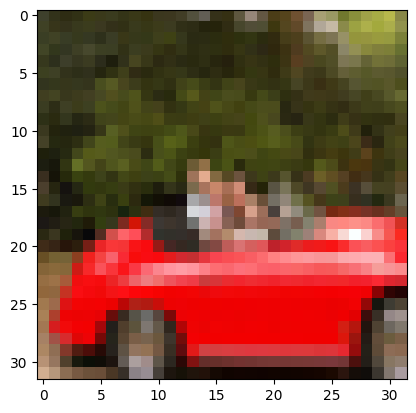

In [6]:
import matplotlib.pyplot as plt
plt.imshow(img)
plt.show()

In [7]:
from torchvision import transforms
dir(transforms)

['AugMix',
 'AutoAugment',
 'AutoAugmentPolicy',
 'CenterCrop',
 'ColorJitter',
 'Compose',
 'ConvertImageDtype',
 'ElasticTransform',
 'FiveCrop',
 'GaussianBlur',
 'Grayscale',
 'InterpolationMode',
 'Lambda',
 'LinearTransformation',
 'Normalize',
 'PILToTensor',
 'Pad',
 'RandAugment',
 'RandomAdjustSharpness',
 'RandomAffine',
 'RandomApply',
 'RandomAutocontrast',
 'RandomChoice',
 'RandomCrop',
 'RandomEqualize',
 'RandomErasing',
 'RandomGrayscale',
 'RandomHorizontalFlip',
 'RandomInvert',
 'RandomOrder',
 'RandomPerspective',
 'RandomPosterize',
 'RandomResizedCrop',
 'RandomRotation',
 'RandomSolarize',
 'RandomVerticalFlip',
 'Resize',
 'TenCrop',
 'ToPILImage',
 'ToTensor',
 'TrivialAugmentWide',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_functional_pil',
 '_functional_tensor',
 '_presets',
 'autoaugment',
 'functional',
 'transforms']

In [8]:
to_tensor = transforms.ToTensor()
img_t = to_tensor(img)
img_t.shape

torch.Size([3, 32, 32])

In [9]:
# convinent
tensor_cifar10 = datasets.CIFAR10(data_path, train=True, download=False,
                                  transform=transforms.ToTensor())

img_t, _ = tensor_cifar10[99]
type(img_t)

torch.Tensor

In [10]:
img_t.shape, img_t.dtype

(torch.Size([3, 32, 32]), torch.float32)

>whereas the values in the original PIL image ranged from 0 to 255, the `ToTensor` transform turns the data into a 32-bit floating-point per channel, scaling the values down from 0.0 to 1.0.

In [11]:
img_t.min(), img_t.max()

(tensor(0.), tensor(1.))

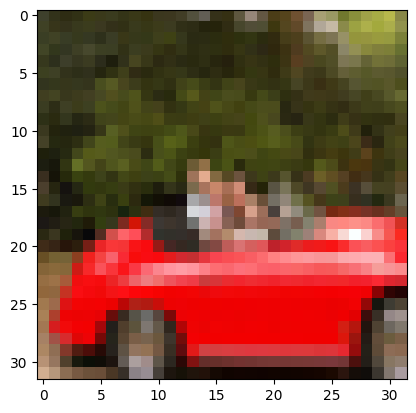

In [12]:
plt.imshow(img_t.permute(1, 2, 0))
plt.show()

>**normalizing data**<br>
>It's good practice to normalize the dataset so that each channel has zero mean and unitary standard deviation.<br>
>keeping the data in the same range means it's more likely that neurons have nonzero gradients and hence, will learn sooner.<br>
>Also, normalizing each channel so that it has the same distribution will ensure that channel information can be mixed and updated through gradient descent using the same learning rate.

In [13]:
import torch
imgs = torch.stack([img_t for img_t, _ in tensor_cifar10], dim=3)
imgs.shape

torch.Size([3, 32, 32, 50000])

In [14]:
mean = imgs.view(3, -1).mean(dim=1)
mean

tensor([0.4914, 0.4822, 0.4465])

In [15]:
std = imgs.view(3, -1).std(dim=1)
std

tensor([0.2470, 0.2435, 0.2616])

In [16]:
transforms.Normalize(mean=mean, std=std)

Normalize(mean=tensor([0.4914, 0.4822, 0.4465]), std=tensor([0.2470, 0.2435, 0.2616]))

In [17]:
transformed_cifar10 = datasets.CIFAR10(
    data_path, train=True, download=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9802377..2.1267893].


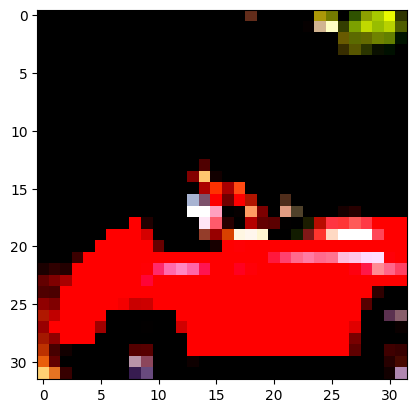

In [18]:
img_t, _ = transformed_cifar10[99]
plt.imshow(img_t.permute(1, 2, 0))
plt.show()

In [19]:
label_map = {0: 0, 2:1}
class_names = ['airplane', 'bird']

cifar2 = [(img, label_map[label]) for img, label in cifar10 if label in [0, 2]]
cifar2_val = [(img, label_map[label]) for img, label in cifar10_val if label in [0, 2]]

In [20]:
import torch.nn as nn

n_out = 2

model = nn.Sequential(
    nn.Linear(
        3072, 
        512
    ),
    nn.Tanh(),
    nn.Linear(
        512, 
        n_out
    )
)

In [21]:
# softmax
import torch.nn as nn
x = torch.tensor([1.0, 2.0, 3.0])
softmax = nn.Softmax(dim=0)
softmax(x), softmax(x).sum()

(tensor([0.0900, 0.2447, 0.6652]), tensor(1.))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8622148..2.0301533].


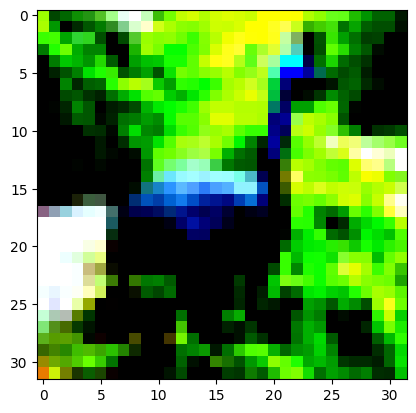

In [22]:
model = nn.Sequential(
    nn.Linear(3072, 512),
    nn.Tanh(),
    nn.Linear(512, 2),
    nn.Softmax(dim=1)
)

cifar2_img = [img for img, _ in cifar2]

transform_func = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

transformed_img = [transform_func(img) for img in cifar2_img]

plt.imshow(transformed_img[0].permute(1, 2, 0))
plt.show()

In [23]:
img_batch = transformed_img[0].view(-1).unsqueeze(0)
out = model(img_batch)
out

tensor([[0.2898, 0.7102]], grad_fn=<SoftmaxBackward0>)

In [24]:
_, index = torch.max(out, dim=1)
index

tensor([1])

In [25]:
model = nn.Sequential(
    nn.Linear(3072, 512),
    nn.Tanh(),
    nn.Linear(512, 2),
    nn.LogSoftmax(dim=1)
)

loss = nn.NLLLoss()
_, label = cifar2[0]
out = model(img_batch)
loss(out, torch.tensor([label]))

tensor(1.0550, grad_fn=<NllLossBackward0>)

In [26]:
# Training the classifier
import torch.optim as optim

model = nn.Sequential(
    nn.Linear(3072, 512),
    nn.Tanh(),
    nn.Linear(512, 2),
    nn.LogSoftmax(dim=1)
)

learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.NLLLoss()
n_epochs = 5

# 在每个训练周期内，一个一个处理数据实际上是对整体梯度的局部更新，对某个数据的优化可能是对其他数据的负优化。
# 但是，这有一个好处，随机梯度可以防止梯度在某个局部最优值中卡住
for epoch in range(n_epochs):
    for img, label in cifar2:
        img_tensor = transform_func(img).view(-1).unsqueeze(0)
        label_tensor = torch.tensor([label])
        
        out = model(img_tensor)
        loss = loss_fn(out, label_tensor)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

C:\Users\hf\AppData\Local\Temp\ipykernel_29368\2552017773.py:29: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:823.)
  print("Epoch: %d, Loss: %f" % (epoch, float(loss)))


Epoch: 0, Loss: 5.727265
Epoch: 1, Loss: 5.605198
Epoch: 2, Loss: 4.810812
Epoch: 3, Loss: 5.078501
Epoch: 4, Loss: 5.220118


In [27]:
# 使用 DataLoader 自动进行数据的打乱和批处理
cifar2_tensor = [(transform_func(img), label) for img, label in cifar2 ]
train_loader = torch.utils.data.DataLoader(cifar2_tensor, batch_size=64, shuffle=True)

model = nn.Sequential(
    nn.Linear(3072, 512),
    nn.Tanh(),
    nn.Linear(512, 2),
    nn.LogSoftmax(dim=1)
)

learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.NLLLoss()
n_epochs = 100

for epoch in range(n_epochs):
    for imgs, labels in train_loader:
        batch_size = imgs.shape[0]
        img_tensor = imgs.view(batch_size, -1)
        label_tensor = torch.tensor(labels)
        out = model(img_tensor)
        loss = loss_fn(out, label_tensor)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

C:\Users\hf\AppData\Local\Temp\ipykernel_29368\2677058585.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  label_tensor = torch.tensor(labels)


Epoch: 0, Loss: 0.409755
Epoch: 1, Loss: 0.469751
Epoch: 2, Loss: 0.787820
Epoch: 3, Loss: 0.340691
Epoch: 4, Loss: 0.189701
Epoch: 5, Loss: 0.231932
Epoch: 6, Loss: 0.318084
Epoch: 7, Loss: 0.563216
Epoch: 8, Loss: 0.291167
Epoch: 9, Loss: 0.631962
Epoch: 10, Loss: 0.587003
Epoch: 11, Loss: 0.434020
Epoch: 12, Loss: 0.342156
Epoch: 13, Loss: 0.227843
Epoch: 14, Loss: 0.364925
Epoch: 15, Loss: 0.380042
Epoch: 16, Loss: 0.125928
Epoch: 17, Loss: 0.139041
Epoch: 18, Loss: 0.218895
Epoch: 19, Loss: 0.218790
Epoch: 20, Loss: 0.334289
Epoch: 21, Loss: 0.338336
Epoch: 22, Loss: 0.206894
Epoch: 23, Loss: 0.364351
Epoch: 24, Loss: 0.246225
Epoch: 25, Loss: 0.123818
Epoch: 26, Loss: 0.277196
Epoch: 27, Loss: 0.399420
Epoch: 28, Loss: 0.157890
Epoch: 29, Loss: 0.348244
Epoch: 30, Loss: 0.117646
Epoch: 31, Loss: 0.234835
Epoch: 32, Loss: 0.190754
Epoch: 33, Loss: 0.158128
Epoch: 34, Loss: 0.248218
Epoch: 35, Loss: 0.195546
Epoch: 36, Loss: 0.119401
Epoch: 37, Loss: 0.028479
Epoch: 38, Loss: 0.336

In [29]:
cifar2_val_tensor = [(transform_func(img), label) for img, label in cifar2_val]
val_loader = torch.utils.data.DataLoader(cifar2_val_tensor, batch_size=64, shuffle=False)
correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in val_loader:
        batch_size = imgs.shape[0]
        outputs = model(imgs.view(batch_size, -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum()) 
        
    print("Accuracy: %f", correct / total)
        

Accuracy: %f 0.8235


In [30]:
model = nn.Sequential(
    nn.Linear(3072, 1024), 
    nn.Tanh(),
    nn.Linear(1024, 512),
    nn.Tanh(),
    nn.Linear(512, 128),
    nn.Tanh(),
    nn.Linear(128, 2)
)
loss_fn = nn.CrossEntropyLoss()

learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
n_epochs = 100

for epoch in range(n_epochs):
    for imgs, labels in train_loader:
        batch_size = imgs.shape[0]
        img_tensor = imgs.view(batch_size, -1)
        label_tensor = torch.tensor(labels)
        out = model(img_tensor)
        loss = loss_fn(out, label_tensor)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

C:\Users\hf\AppData\Local\Temp\ipykernel_29368\3884790461.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  label_tensor = torch.tensor(labels)


Epoch: 0, Loss: 0.407062
Epoch: 1, Loss: 0.202673
Epoch: 2, Loss: 0.469102
Epoch: 3, Loss: 0.441677
Epoch: 4, Loss: 0.575065
Epoch: 5, Loss: 0.746328
Epoch: 6, Loss: 0.420276
Epoch: 7, Loss: 0.199244
Epoch: 8, Loss: 0.467764
Epoch: 9, Loss: 0.319737
Epoch: 10, Loss: 0.796331
Epoch: 11, Loss: 0.722553
Epoch: 12, Loss: 0.548540
Epoch: 13, Loss: 0.266693
Epoch: 14, Loss: 0.377951
Epoch: 15, Loss: 0.560723
Epoch: 16, Loss: 0.357919
Epoch: 17, Loss: 0.413299
Epoch: 18, Loss: 0.176511
Epoch: 19, Loss: 0.292016
Epoch: 20, Loss: 0.328384
Epoch: 21, Loss: 0.571346
Epoch: 22, Loss: 0.092045
Epoch: 23, Loss: 0.528962
Epoch: 24, Loss: 0.259166
Epoch: 25, Loss: 0.156456
Epoch: 26, Loss: 0.324515
Epoch: 27, Loss: 0.289720
Epoch: 28, Loss: 0.247699
Epoch: 29, Loss: 0.483392
Epoch: 30, Loss: 0.205378
Epoch: 31, Loss: 0.108988
Epoch: 32, Loss: 0.122765
Epoch: 33, Loss: 0.365923
Epoch: 34, Loss: 0.122250
Epoch: 35, Loss: 0.478614
Epoch: 36, Loss: 0.020817
Epoch: 37, Loss: 0.116184
Epoch: 38, Loss: 0.094

In [34]:
cifar2_val_tensor = [(transform_func(img), label) for img, label in cifar2_val]
val_loader = torch.utils.data.DataLoader(cifar2_val_tensor, batch_size=64, shuffle=False)
correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in val_loader:
        batch_size = imgs.shape[0]
        outputs = model(imgs.view(batch_size, -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum()) 
        
    print("Accuracy: %f", correct / total)

Accuracy: %f 0.7975


In [35]:
numel_list = [p.numel() 
              for p in model.parameters() 
              if p.requires_grad == True]
sum(numel_list), numel_list

(3737474, [3145728, 1024, 524288, 512, 65536, 128, 256, 2])